In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt

""" 
参数列表:
1.vocab_size=27
2.block_size=3
3.N=228146
4.tr,dev,text=0.8,0.1,0.1
5.emb_dim=10
6.hidden_size=100
7.num_parameters=
8.iters=10000
9.alpha=0.1
10.batch_size=32
"""


' \n参数列表:\n1.vocab_size=27\n2.block_size=3\n3.N=228146\n4.tr,dev,text=0.8,0.1,0.1\n5.emb_dim=10\n6.hidden_size=100\n7.num_parameters=\n8.iters=10000\n9.alpha=0.1\n10.batch_size=32\n'

In [ ]:
words = open("names.txt", "r").read().splitlines()
chars = sorted(list(set("".join(words))))
stoi = {".": 0}
stoi.update({s: i + 1 for i, s in enumerate(chars)})
itos = {i: s for s, i in stoi.items()}
vocab_size = len(stoi)

In [ ]:
block_size = 3
X = []
Y = []
for w in words:
    context = [0] * block_size
    for ch in w + ".":
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

N = len(X)
X = torch.tensor(X)
Y = torch.tensor(Y)


In [ ]:
train_size = 0.8
dev_size = 0.1
test_size = 0.1
indices = torch.randperm(N)
n1 = int(N * train_size)
n2 = int(N * (train_size + dev_size))
X_train = X[indices[:n1]]
Y_train = Y[indices[:n1]]
X_dev = X[indices[n1:n2]]
Y_dev = Y[indices[n1:n2]]
X_test = X[indices[n2:]]
Y_test = Y[indices[n2:]]

In [ ]:
g = torch.Generator().manual_seed(2147483647)
emb_dim = 10
C = torch.randn((vocab_size, emb_dim), generator=g)
hidden_size = 200
fan_in = block_size * emb_dim
W1 = torch.randn((fan_in, hidden_size), generator=g) * (5 / 3) / (fan_in) ** 0.5

bngain = torch.ones((1, hidden_size))
bnbias = torch.zeros((1, hidden_size))
bnmean_running = torch.zeros((1, hidden_size))
bnvar_running = torch.ones((1, hidden_size))
momentum = 0.001

W2 = torch.randn((hidden_size, vocab_size), generator=g) * 0.01
b2 = torch.zeros((vocab_size,))

parameters = [W1, W2, b2, bngain, bnbias]
num_parameters = sum(p.nelement() for p in parameters)


In [ ]:
# 验证一下
g_check = torch.Generator().manual_seed(2147483647)
batch_size_check = 128
C_c = C.clone().detach().requires_grad_(True)
W1_c = W1.clone().detach().requires_grad_(True)
bngain_c = bngain.clone().detach().requires_grad_(True)
bnbias_c = bnbias.clone().detach().requires_grad_(True)
W2_c = W2.clone().detach().requires_grad_(True)
b2_c = b2.clone().detach().requires_grad_(True)

ix_check = torch.randint(0, X_train.shape[0], (batch_size_check,), generator=g_check)
X_b_check = X_train[ix_check]
Y_b_check = Y_train[ix_check]

emb_c = C_c[X_b_check]
emb_flact_c = emb_c.reshape(emb_c.shape[0], -1)
hprebn_c = emb_flact_c @ W1_c
bnmean_c = hprebn_c.mean(0, keepdim=True)
bnvar_c = hprebn_c.var(0, keepdim=True, unbiased=True)
bnraw_c = (hprebn_c - bnmean_c) / torch.sqrt(bnvar_c + 1e-5)
z1_c = bngain_c * bnraw_c + bnbias_c
a1_c = torch.tanh(z1_c)
logits_c = a1_c @ W2_c + b2_c
loss_c = F.cross_entropy(logits_c, Y_b_check)
loss_c.backward()
# 手写
emb = C[X_b_check]
emb_flact = emb.reshape(emb.shape[0], -1)
hprebn = emb_flact @ W1
# bn
bnmean = hprebn.mean(0, keepdim=True)
bndiff = hprebn - bnmean
bndiff2 = bndiff**2
bnvar = bndiff2.sum(0, keepdim=True) / (batch_size_check - 1)
bnvar_inv = (bnvar + 1e-5) ** -0.5
bnraw = bndiff * bnvar_inv
z1 = bngain * bnraw + bnbias  # 广播
a1 = torch.tanh(z1)

""" 
hprebn: torch.Size([128, 200])
bnmean: torch.Size([1, 200])
bndiff: torch.Size([128, 200])
bndiff2: torch.Size([128, 200])
bnvar: torch.Size([1, 200])
bnvar_inv: torch.Size([1, 200])
bnraw: torch.Size([128, 200])
bngain: torch.Size([1, 200])
bnbias: torch.Size([1, 200])

"""

logits = a1 @ W2 + b2
logits_max = logits.max(1, keepdim=True).values
logits_shifted = logits - logits_max
counts = logits_shifted.exp()
probs = counts / counts.sum(1, keepdim=True)
loss = -probs[range(batch_size_check), Y_b_check].log().mean()
# backward
dlogits = probs.clone()
dlogits[range(batch_size_check), Y_b_check] -= 1.0
dlogits /= batch_size_check
dW2 = a1.T @ dlogits
db2 = dlogits.sum(0)
da1 = dlogits @ W2.T
dz1 = da1 * (1.0 - a1**2)
dbngain = (dz1 * bnraw).sum(0, keepdim=True)
dbnbias = dz1.sum(0, keepdim=True)
dbnraw = dz1 * bngain
dbndiff_1 = dbnraw * bnvar_inv
dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim=True)
dbnvar = dbnvar_inv * (-0.5 * (bnvar + 1e-5) ** -1.5)
dbndiff2 = dbnvar * (1.0 / (batch_size_check - 1)) * torch.ones_like(bndiff2)
dbndiff_2 = dbndiff2 * 2 * bndiff
dbndiff = dbndiff_1 + dbndiff_2
dhprebn_1 = dbndiff.clone()
dbnmean = (-dbndiff).sum(0, keepdim=True)
dhprebn_2 = dbnmean * (1.0 / batch_size_check) * torch.ones_like(hprebn)
dhprebn = dhprebn_1 + dhprebn_2
dW1 = emb_flact.T @ dhprebn
demb_flact = dhprebn @ W1.T
demb = demb_flact.reshape(emb.shape)
dC = torch.zeros_like(C)
dC.index_add_(0, X_b_check.flatten(), demb.view(-1, demb.shape[-1]))
None


In [ ]:
def compare(name, manual, auto):
    match = torch.allclose(manual, auto, atol=1e-6)
    max_diff = (manual - auto).abs().max().item()
    status = "✅ 一致" if match else "❌ 不一致"
    print(f"{name:8s}  {status}   最大差异: {max_diff:.2e}")


print("=" * 45)
print("梯度核对结果(手写 vs autograd, 含BatchNorm)")
print("=" * 45)
compare("dW2", dW2, W2_c.grad)
compare("db2", db2, b2_c.grad)
compare("dW1", dW1, W1_c.grad)
compare("dbngain", dbngain, bngain_c.grad)  # === 新增 ===
compare("dbnbias", dbnbias, bnbias_c.grad)  # === 新增 ===
compare("dC ", dC, C_c.grad)
print("=" * 45)
print(
    f"手写loss: {(-probs[range(batch_size_check), Y_b_check].log().mean()).item():.6f}"
)
print(f"autograd loss: {loss_c.item():.6f}")

梯度核对结果(手写 vs autograd, 含BatchNorm)
dW2       ✅ 一致   最大差异: 2.24e-08
db2       ✅ 一致   最大差异: 1.49e-08
dW1       ✅ 一致   最大差异: 6.98e-10
dbngain   ✅ 一致   最大差异: 1.75e-10
dbnbias   ✅ 一致   最大差异: 5.82e-10
dC        ✅ 一致   最大差异: 1.11e-09
手写loss: 3.301868
autograd loss: 3.301868


In [ ]:
iters = 10000
alpha = 0.1
batch_size = 128
alpha_decay_start = int(0.8 * iters)
alpha_decayed = alpha / 10
from collections import defaultdict

logger = defaultdict(list)
lossi = []


# A基础统计
@torch.no_grad()
def log_stats(
    step,
    hprebn,
    bnraw,
    bnmean,
    bnvar,
    a1,
    bngain,
    bnbias,
    bnmean_running,
    bnvar_running,
):
    logger["step"].append(step)
    logger["hprebn_std"].append(hprebn.std().item())
    logger["bnraw_std"].append(bnraw.std().item())
    logger["bnraw_mean"].append(bnraw.mean().item())
    logger["sat_rate"].append((a1.abs() > 0.99).float().mean().item())
    logger["dead_rate"].append((a1.var(0) < 1e-4).float().mean().item())
    logger["bngain_mean"].append(bngain.mean().item())
    logger["bngain_min"].append(bngain.min().item())
    logger["bnbias_mean"].append(bnbias.mean().item())
    logger["bnmean_gap"].append((bnmean - bnmean_running).abs().mean().item())
    logger["bnvar_gap"].append((bnvar - bnvar_running).abs().mean().item())


def log_ud_ratio(step, params_and_grads, lr):

    for name, (p, g) in params_and_grads.items():
        ud = (lr * g).std() / p.std()
        logger[f"ud_{name}"].append(ud.log10().item())


@torch.no_grad()
def eval_loss(
    step, x, y, split_name, C, W1, bngain, bnbias, W2, b2, bnmean_running, bnvar_running
):
    emb = C[x]
    emb_flat = emb.reshape(emb.shape[0], -1)
    hpre = emb_flat @ W1
    z = bngain * (hpre - bnmean_running) / torch.sqrt(bnvar_running + 1e-5) + bnbias
    a = torch.tanh(z)
    logits = a @ W2 + b2
    loss = torch.nn.functional.cross_entropy(logits, y)
    logger[f"{split_name}_loss_eval"].append((step, loss.item()))
    return loss.item()

In [ ]:
for i in range(iters):
    ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
    X_b, Y_b = X_train[ix], Y_train[ix]
    emb = C[X_b]
    emb_flact = emb.reshape(emb.shape[0], -1)
    hprebn = emb_flact @ W1

    bnmean = hprebn.mean(0, keepdim=True)
    bndiff = hprebn - bnmean
    bndiff2 = bndiff**2
    bnvar = bndiff2.sum(0, keepdim=True) / (batch_size - 1)
    bnvar_inv = (bnvar + 1e-5) ** -0.5
    bnraw = bndiff * bnvar_inv
    z1 = bngain * bnraw + bnbias  #
    a1 = torch.tanh(z1)
    logits = a1 @ W2 + b2
    logits_max = logits.max(1, keepdim=True).values
    logits_shifted = logits - logits_max
    counts = logits_shifted.exp()
    probs = counts / counts.sum(1, keepdim=True)
    loss = -probs[range(batch_size_check), Y_b_check].log().mean()
    lossi.append(loss.item())
    # backward
    dlogits = probs.clone()
    dlogits[range(batch_size_check), Y_b_check] -= 1.0
    dlogits /= batch_size_check
    dW2 = a1.T @ dlogits
    db2 = dlogits.sum(0)
    da1 = dlogits @ W2.T
    dz1 = da1 * (1.0 - a1**2)
    dbngain = (dz1 * bnraw).sum(0, keepdim=True)
    dbnbias = dz1.sum(0, keepdim=True)
    dbnraw = dz1 * bngain
    dbndiff_1 = dbnraw * bnvar_inv
    dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim=True)
    dbnvar = dbnvar_inv * (-0.5 * (bnvar + 1e-5) ** -1.5)
    dbndiff2 = dbnvar * (1.0 / (batch_size_check - 1)) * torch.ones_like(bndiff2)
    dbndiff_2 = dbndiff2 * 2 * bndiff
    dbndiff = dbndiff_1 + dbndiff_2
    dhprebn_1 = dbndiff.clone()
    dbnmean = (-dbndiff).sum(0, keepdim=True)
    dhprebn_2 = dbnmean * (1.0 / batch_size_check) * torch.ones_like(hprebn)
    dhprebn = dhprebn_1 + dhprebn_2
    dW1 = emb_flact.T @ dhprebn
    demb_flact = dhprebn @ W1.T
    demb = demb_flact.reshape(emb.shape)
    dC = torch.zeros_like(C)
    dC.index_add_(0, X_b_check.flatten(), demb.view(-1, demb.shape[-1]))

    cur_alpha = alpha if i < alpha_decay_start else alpha_decayed

    if i % 100 == 0:
        log_stats(
            i,
            hprebn,
            bnraw,
            bnmean,
            bnvar,
            a1,
            bngain,
            bnbias,
            bnmean_running,
            bnvar_running,
        )

        params_and_grads = {
            "W1": (W1, dW1),
            "W2": (W2, dW2),
            "bngain": (bngain, dbngain),
            "bnbias": (bnbias, dbnbias),
        }
        log_ud_ratio(i, params_and_grads, cur_alpha)

    if i % 1000 == 0:
        eval_loss(
            i,
            X_train[:5000],
            Y_train[:5000],
            "train",
            C,
            W1,
            bngain,
            bnbias,
            W2,
            b2,
            bnmean_running,
            bnvar_running,
        )
        eval_loss(
            i,
            X_dev,
            Y_dev,
            "val",
            C,
            W1,
            bngain,
            bnbias,
            W2,
            b2,
            bnmean_running,
            bnvar_running,
        )

    bnmean_running = (1 - momentum) * bnmean_running + momentum * bnmean
    bnvar_running = (1 - momentum) * bnvar_running + momentum * bnvar

    W2 -= cur_alpha * dW2
    b2 -= cur_alpha * db2
    W1 -= cur_alpha * dW1
    bngain -= cur_alpha * dbngain
    bnbias -= cur_alpha * dbnbias
    C -= cur_alpha * dC




**A组 — `log_stats`**

| 指标 | 含义 | 异常信号 |
|---|---|---|
| `hprebn_std` | BN 之前 pre-activation 的标准差 | 随训练缓慢漂移正常；突然剧烈跳变/爆炸 → 前层梯度可能爆炸 |
| `bnraw_std` / `bnraw_mean` | BN 标准化后的值，理论应恒定在 std≈1, mean≈0 | 明显偏离 0/1 → BN 实现本身有 bug（优先查这个） |
| `sat_rate` | tanh 饱和区（\|a1\|>0.99）样本占比 | 长期 >5~10% → 梯度传不回去，学习率/初始化/BN尺度需要查 |
| `dead_rate` | 输出方差接近0的神经元占比 | 持续升高 → 部分神经元被"学死"，学习率过大或某些W1列异常 |
| `bngain_mean` / `bngain_min` | γ 的均值/最小值 | 大量趋近0 → 网络主动关闭很多神经元，结合 dead_rate 判断是否合理 |
| `bnmean_gap` / `bnvar_gap` | 当前batch统计量 vs 滑动平均统计量的差距 | 训练早期大是正常；后期仍不收敛 → momentum设置不当或batch太小 |

**B组 — `log_ud_ratio`**

| 指标 | 含义 | 异常信号 |
|---|---|---|
| `ud_<参数名>` | 这一步更新幅度相对参数自身尺度的比例（log10） | 健康值约 -3；明显偏高(>-2) → 学习率太大/梯度爆炸；明显偏低(<-4) → 这层几乎没在学 |

**C组 — `eval_loss`**

| 指标 | 含义 | 异常信号 |
|---|---|---|
| `train_loss_eval` / `val_loss_eval` | 用 running 统计量（而非batch统计量）算出的loss，代表真实推理/生成时的表现 | train持续降但这个停滞/上升 → 除了过拟合，也要怀疑running统计量没收敛好 |



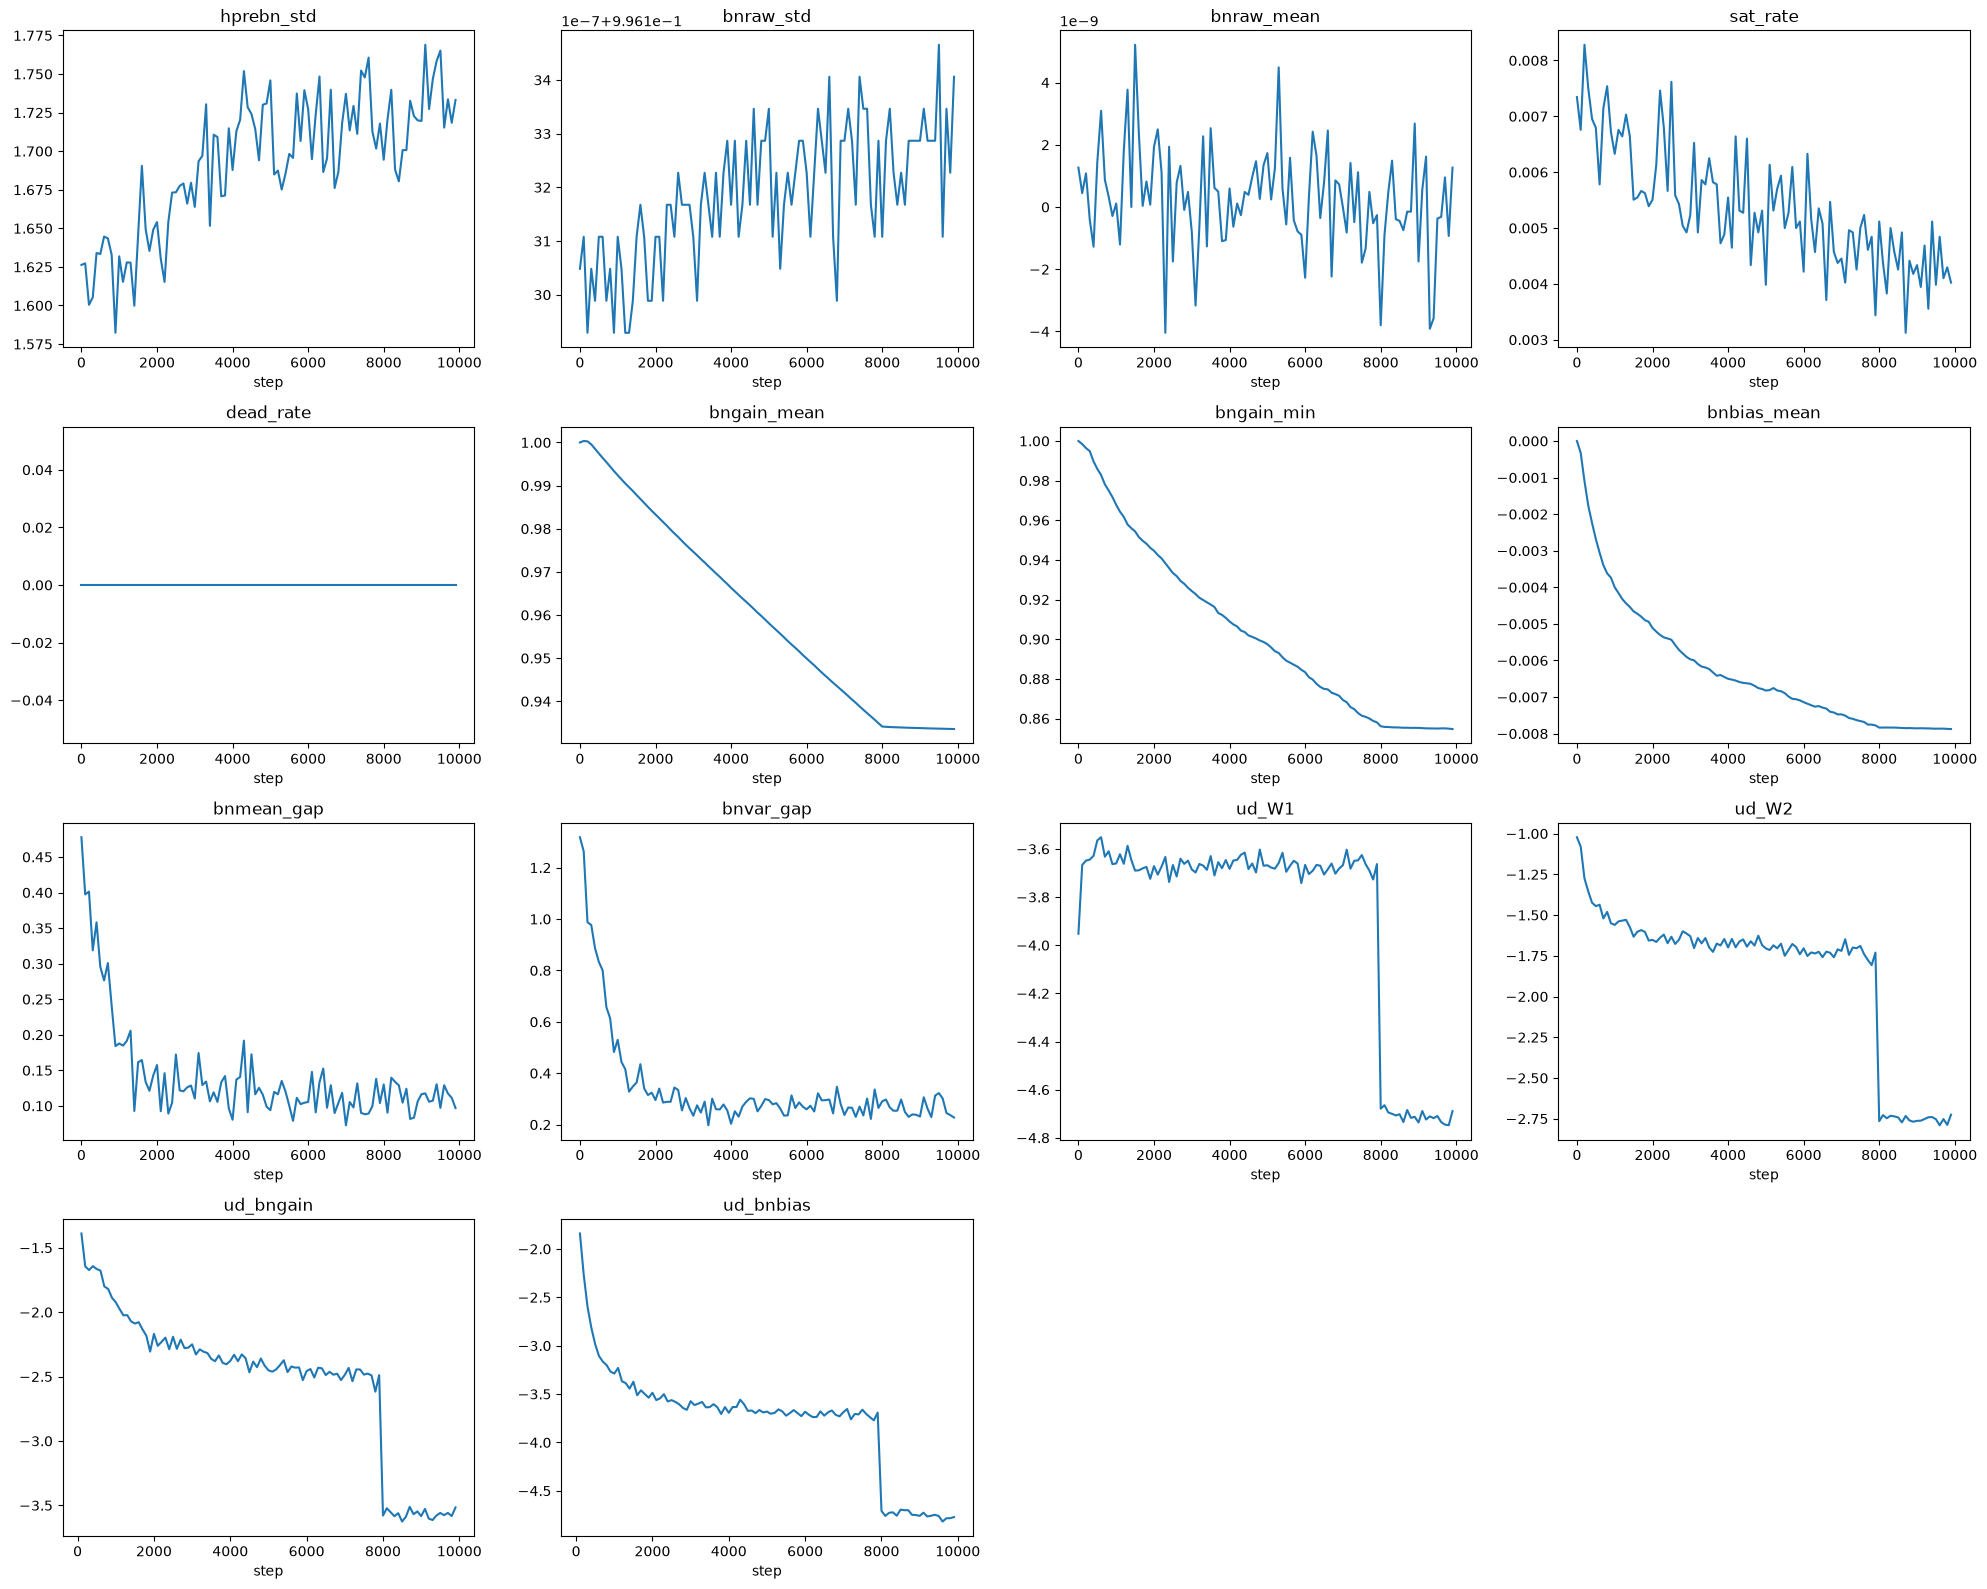

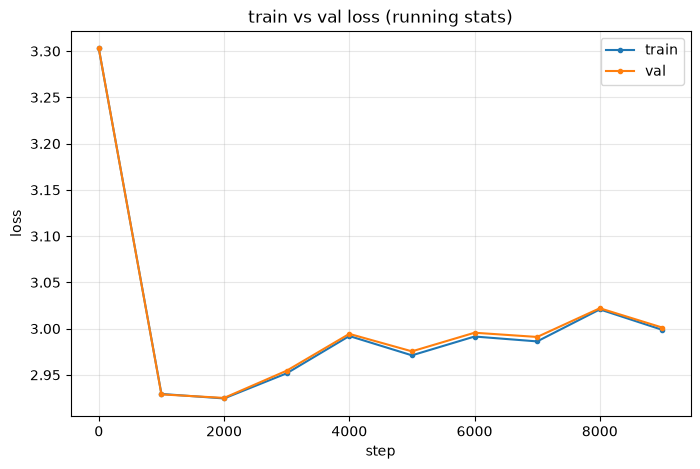

In [ ]:
# ============================================================
# 图1：主要监控指标（A组 + B组），一次性画出所有曲线
# ============================================================

plot_keys = [
    "hprebn_std",
    "bnraw_std",
    "bnraw_mean",
    "sat_rate",
    "dead_rate",
    "bngain_mean",
    "bngain_min",
    "bnbias_mean",
    "bnmean_gap",
    "bnvar_gap",
    "ud_W1",
    "ud_W2",
    "ud_bngain",
    "ud_bnbias",
]

# 只画logger里实际存在的key，避免某些没记录到时报错
plot_keys = [k for k in plot_keys if k in logger]

n = len(plot_keys)
ncols = 4
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()

for ax, k in zip(axes, plot_keys):
    ax.plot(logger["step"], logger[k])
    ax.set_title(k)
    ax.set_xlabel("step")

# 多余的子图（如果 n 不能整除 ncols）隐藏掉
for ax in axes[n:]:
    ax.axis("off")

plt.tight_layout()
plt.savefig("bn_monitor.png", dpi=150)
plt.show()


# ============================================================
# 图2：train vs val loss（用running统计量算的，单独一张图）
# ============================================================

plt.figure(figsize=(8, 5))
for split in ["train", "val"]:
    key = f"{split}_loss_eval"
    if key in logger and len(logger[key]) > 0:
        steps, losses = zip(*logger[key])
        plt.plot(steps, losses, label=split, marker="o", markersize=3)

plt.xlabel("step")
plt.ylabel("loss")
plt.title("train vs val loss (running stats)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("bn_loss_curve.png", dpi=150)
plt.show()

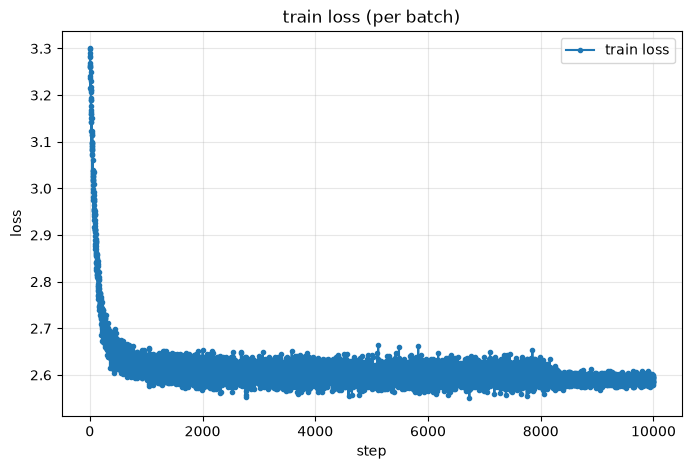

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(lossi, label="train loss", marker="o", markersize=3)
plt.xlabel("step")
plt.ylabel("loss")
plt.title("train loss (per batch)")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig("bn_loss_per_batch.png", dpi=150)

In [ ]:
# 网格搜索
def init_params(emb_dim, hidden_size, vocab_size, block_size, g):
    C = torch.randn((vocab_size, emb_dim), generator=g)
    fan_in = block_size * emb_dim
    W1 = torch.randn((fan_in, hidden_size), generator=g) * (5 / 3) / (fan_in) ** 0.5
    bngain = torch.ones((1, hidden_size))
    bnbias = torch.zeros((1, hidden_size))
    W2 = torch.randn((hidden_size, vocab_size), generator=g) * 0.01
    b2 = torch.zeros((vocab_size,))
    bnmean_running = torch.zeros((1, hidden_size))
    bnvar_running = torch.ones((1, hidden_size))
    return C, W1, bngain, bnbias, W2, b2, bnmean_running, bnvar_running


@torch.no_grad()
def eval_split(x, y, C, W1, bnbias, bngain, W2, b2, bnmean_running, bnvar_running):
    emb = C[x]
    emb_flact = emb.reshape(emb.shape[0], -1)
    hprebn = emb_flact @ W1
    bnraw = (hprebn - bnmean_running) / torch.sqrt(bnvar_running + 1e-5)
    z1 = bngain * bnraw + bnbias
    a1 = torch.tanh(z1)
    logits = a1 @ W2 + b2
    loss = F.cross_entropy(logits, y)
    return loss.item()


def train_one_config(
    alpha,
    hidden_size,
    alpha_decay_start,
    alpha_decayed,
    iters=10000,
    batch_size=128,
    X_train=X_train,
    Y_train=Y_train,
    emb_dim=10,
    block_size=3,
    vocab_size=vocab_size,
):
    g = torch.Generator().manual_seed(42)
    C, W1, bngain, bnbias, W2, b2, bnmean_running, bnvar_running = init_params(
        emb_dim, hidden_size, vocab_size, block_size, g
    )
    for i in range(iters):
        ix = torch.randint(0, X_train.shape[0], (batch_size,), generator=g)
        X_b, Y_b = X_train[ix], Y_train[ix]
        emb = C[X_b]
        emb_flact = emb.reshape(emb.shape[0], -1)
        hprebn = emb_flact @ W1
        bnmean = hprebn.mean(0, keepdim=True)
        bndiff = hprebn - bnmean
        bndiff2 = bndiff**2
        bnvar = bndiff2.sum(0, keepdim=True) / (batch_size - 1)
        bnvar_inv = (bnvar + 1e-5) ** -0.5
        bnraw = bndiff * bnvar_inv
        z1 = bngain * bnraw + bnbias  #
        a1 = torch.tanh(z1)
        logits = a1 @ W2 + b2
        logits_max = logits.max(1, keepdim=True).values
        logits_shifted = logits - logits_max
        counts = logits_shifted.exp()
        probs = counts / counts.sum(1, keepdim=True)
        loss = -probs[range(batch_size), Y_b].log().mean()
        # backward
        dlogits = probs.clone()
        dlogits[range(batch_size), Y_b] -= 1.0
        dlogits /= batch_size
        dW2 = a1.T @ dlogits
        db2 = dlogits.sum(0)
        da1 = dlogits @ W2.T
        dz1 = da1 * (1.0 - a1**2)
        dbngain = (dz1 * bnraw).sum(0, keepdim=True)
        dbnbias = dz1.sum(0, keepdim=True)
        dbnraw = dz1 * bngain
        dbndiff_1 = dbnraw * bnvar_inv
        dbnvar_inv = (dbnraw * bndiff).sum(0, keepdim=True)
        dbnvar = dbnvar_inv * (-0.5 * (bnvar + 1e-5) ** -1.5)
        dbndiff2 = dbnvar * (1.0 / (batch_size - 1)) * torch.ones_like(bndiff2)
        dbndiff_2 = dbndiff2 * 2 * bndiff
        dbndiff = dbndiff_1 + dbndiff_2
        dhprebn_1 = dbndiff.clone()
        dbnmean = (-dbndiff).sum(0, keepdim=True)
        dhprebn_2 = dbnmean * (1.0 / batch_size) * torch.ones_like(hprebn)
        dhprebn = dhprebn_1 + dhprebn_2
        dW1 = emb_flact.T @ dhprebn
        demb_flact = dhprebn @ W1.T
        demb = demb_flact.reshape(emb.shape)
        dC = torch.zeros_like(C)
        dC.index_add_(0, X_b.flatten(), demb.view(-1, demb.shape[-1]))
        cur_alpha = alpha if i < alpha_decay_start else alpha_decayed
        with torch.no_grad():
            bnmean_running = (1 - momentum) * bnmean_running + momentum * bnmean
            bnvar_running = (1 - momentum) * bnvar_running + momentum * bnvar
        W2 -= cur_alpha * dW2
        b2 -= cur_alpha * db2
        W1 -= cur_alpha * dW1
        bngain -= cur_alpha * dbngain
        bnbias -= cur_alpha * dbnbias
        C -= cur_alpha * dC

    dev_loss = eval_split(
        X_dev, Y_dev, C, W1, bnbias, bngain, W2, b2, bnmean_running, bnvar_running
    )
    return dev_loss


alpha_grid = [0.3]
hidden_size_grid = [600, 700, 800]
batch_size = [128, 256, 512]
iters = 10000


def make_decayed_alpha(alpha, iters):
    decay_factor = 10  # 可以根据需要调整衰减因子
    return int(iters * 0.8), alpha / decay_factor


import itertools

results = []
for alpha, hidden_size, batch_size in itertools.product(
    alpha_grid, hidden_size_grid, batch_size
):
    alpha_decay_start, alpha_decayed = make_decayed_alpha(alpha, iters)
    dev_loss = train_one_config(
        alpha=alpha,
        hidden_size=hidden_size,
        batch_size=batch_size,
        alpha_decay_start=alpha_decay_start,
        alpha_decayed=alpha_decayed,
    )
    results.append(
        {
            "alpha": alpha,
            "hidden_size": hidden_size,
            "batch_size": batch_size,
            "dev_loss": dev_loss,
        }
    )
    print(
        f"alpha: {alpha}, hidden_size: {hidden_size}, batch_size: {batch_size}, dev_loss: {dev_loss:.4f}"
    )

alpha: 0.3, hidden_size: 600, batch_size: 128, dev_loss: 2.1352
alpha: 0.3, hidden_size: 600, batch_size: 256, dev_loss: 2.1199
alpha: 0.3, hidden_size: 600, batch_size: 512, dev_loss: 2.1100
alpha: 0.3, hidden_size: 700, batch_size: 128, dev_loss: 2.1296
alpha: 0.3, hidden_size: 700, batch_size: 256, dev_loss: 2.1140
alpha: 0.3, hidden_size: 700, batch_size: 512, dev_loss: 2.1048
alpha: 0.3, hidden_size: 800, batch_size: 128, dev_loss: 2.1293
alpha: 0.3, hidden_size: 800, batch_size: 256, dev_loss: 2.1131
alpha: 0.3, hidden_size: 800, batch_size: 512, dev_loss: 2.1039


In [ ]:
""" 

alpha: 0.01, hidden_size: 100, dev_loss: 2.4160
alpha: 0.01, hidden_size: 200, dev_loss: 2.3838
alpha: 0.01, hidden_size: 300, dev_loss: 2.3558
alpha: 0.01, hidden_size: 400, dev_loss: 2.3398
alpha: 0.01, hidden_size: 500, dev_loss: 2.3307
alpha: 0.01, hidden_size: 600, dev_loss: 2.3232
alpha: 0.05, hidden_size: 100, dev_loss: 2.2788
alpha: 0.05, hidden_size: 200, dev_loss: 2.2544
alpha: 0.05, hidden_size: 300, dev_loss: 2.2372
alpha: 0.05, hidden_size: 400, dev_loss: 2.2248
alpha: 0.05, hidden_size: 500, dev_loss: 2.2190
alpha: 0.05, hidden_size: 600, dev_loss: 2.2118
alpha: 0.1, hidden_size: 100, dev_loss: 2.2331
alpha: 0.1, hidden_size: 200, dev_loss: 2.2084
alpha: 0.1, hidden_size: 300, dev_loss: 2.1941
alpha: 0.1, hidden_size: 400, dev_loss: 2.1836
alpha: 0.1, hidden_size: 500, dev_loss: 2.1770
alpha: 0.1, hidden_size: 600, dev_loss: 2.1697
alpha: 0.2, hidden_size: 100, dev_loss: 2.1981
alpha: 0.2, hidden_size: 200, dev_loss: 2.1720
alpha: 0.2, hidden_size: 300, dev_loss: 2.1605
alpha: 0.2, hidden_size: 400, dev_loss: 2.1515
alpha: 0.2, hidden_size: 500, dev_loss: 2.1454
alpha: 0.2, hidden_size: 600, dev_loss: 2.1403
alpha: 0.3, hidden_size: 100, dev_loss: 2.1839
alpha: 0.3, hidden_size: 200, dev_loss: 2.1596
alpha: 0.3, hidden_size: 300, dev_loss: 2.1484
alpha: 0.3, hidden_size: 400, dev_loss: 2.1418
alpha: 0.3, hidden_size: 500, dev_loss: 2.1369
alpha: 0.3, hidden_size: 600, dev_loss: 2.1352
alpha: 0.4, hidden_size: 100, dev_loss: 2.1794
alpha: 0.4, hidden_size: 200, dev_loss: 2.1566
alpha: 0.4, hidden_size: 300, dev_loss: 2.1450
alpha: 0.4, hidden_size: 400, dev_loss: 2.1421
alpha: 0.4, hidden_size: 500, dev_loss: 2.1383
alpha: 0.4, hidden_size: 600, dev_loss: 2.1392
alpha: 0.5, hidden_size: 100, dev_loss: 2.1774
alpha: 0.5, hidden_size: 200, dev_loss: 2.1585
alpha: 0.5, hidden_size: 300, dev_loss: 2.1470
alpha: 0.5, hidden_size: 400, dev_loss: 2.1475
alpha: 0.5, hidden_size: 500, dev_loss: 2.1441
alpha: 0.5, hidden_size: 600, dev_loss: 2.1460



alpha: 0.3, hidden_size: 600, dev_loss: 2.1352
alpha: 0.3, hidden_size: 700, dev_loss: 2.1296
alpha: 0.3, hidden_size: 800, dev_loss: 2.1293

"""


' \n\nalpha: 0.01, hidden_size: 100, dev_loss: 2.4160\nalpha: 0.01, hidden_size: 200, dev_loss: 2.3838\nalpha: 0.01, hidden_size: 300, dev_loss: 2.3558\nalpha: 0.01, hidden_size: 400, dev_loss: 2.3398\nalpha: 0.01, hidden_size: 500, dev_loss: 2.3307\nalpha: 0.01, hidden_size: 600, dev_loss: 2.3232\nalpha: 0.05, hidden_size: 100, dev_loss: 2.2788\nalpha: 0.05, hidden_size: 200, dev_loss: 2.2544\nalpha: 0.05, hidden_size: 300, dev_loss: 2.2372\nalpha: 0.05, hidden_size: 400, dev_loss: 2.2248\nalpha: 0.05, hidden_size: 500, dev_loss: 2.2190\nalpha: 0.05, hidden_size: 600, dev_loss: 2.2118\nalpha: 0.1, hidden_size: 100, dev_loss: 2.2331\nalpha: 0.1, hidden_size: 200, dev_loss: 2.2084\nalpha: 0.1, hidden_size: 300, dev_loss: 2.1941\nalpha: 0.1, hidden_size: 400, dev_loss: 2.1836\nalpha: 0.1, hidden_size: 500, dev_loss: 2.1770\nalpha: 0.1, hidden_size: 600, dev_loss: 2.1697\nalpha: 0.2, hidden_size: 100, dev_loss: 2.1981\nalpha: 0.2, hidden_size: 200, dev_loss: 2.1720\nalpha: 0.2, hidden_siz